# Packages

In [1]:
import numpy as np
import pandas as pd
import os 

import warnings
warnings.filterwarnings('ignore')

# Choose directory
directory = "C:/Users/Fede/OneDrive/Projects/prorindes"
os.chdir(directory)

files_datain = "data/raw_data/"
files_dataout = "data/processed_data/"
files_plots = "plots/"


In [2]:
# scripts with all plot packages and functions
import Scripts.functions_plots as fp
# create_base_map, facet_plot, map_plot, pyplot package and others

# Import files

In [3]:
# Import data
df_yield = pd.read_csv(files_dataout + "yield_averaged_across_management_soil.csv")

df_precip = pd.read_csv(files_dataout + "precipitation_new.csv")

df_locations = pd.read_csv(files_dataout + "location_info.csv")

In [5]:
# reorder categories!!
order = ["Reconquista","Paraná","Gualeguaychú","Río Cuarto","Marcos Juárez",
         "Laboulaye","Junín","Pehuajó","Nueve de Julio","Coronel Suárez","Tandil","Tres Arroyos"]

df_yield['location'] = df_yield["location"].astype("category").cat.reorder_categories(order)
df_locations['location'] = df_locations["location"].astype("category").cat.reorder_categories(order)
df_precip['location'] = df_precip["location"].astype("category").cat.reorder_categories(order)


## Merge yield and precipitation data

In [6]:
# Merge data using "right join" (precipitation)
# Each Julian day will hacve an associated yield (correspondent to the year)

df_merge = pd.merge(df_yield[["location","year","yield_kg_ha","initial_sw"]],
             df_precip,
             on=["location","year"], how = "right").dropna()


# Calculate correlations

## Montecarlo experiment

- The Montecarlo experiment starts from the Julian Day 150
- We iterate 500 times, subsampling from **years**

In [13]:
# We puzt the simulation in a context of a function to avoid unnecesary objects

def montecarlo_sim(data = df_merge):
    np.random.seed(42)
    df_filtered = data[data["julian_day"] > 150].copy()
    years = df_filtered["year"].unique()
    list_simulation = []
    for i in range (0,500):
        years_sub = np.random.choice(years, size= int(len(years)*0.6),replace=False)
        
        df_subsample = df_filtered[df_filtered["year"].isin(years_sub)]
        result = (
        df_subsample
        .groupby(["location", "julian_day", "initial_sw"])
        .apply(lambda g: pd.Series({
            "pearson": g["prcp_sum_30_rollmean5"].corr(g["yield_kg_ha"]),
            "total_values": len(g)
        }))
        .reset_index()
        )
        result["sim_number"] = i+1
        list_simulation.append(result)
    df_simulations = pd.concat(list_simulation,ignore_index=True )
    return df_simulations

df_simulations = montecarlo_sim(data=df_merge)


### Critical period with Montecarlo

In [14]:
indices = df_simulations.groupby(["location","initial_sw","sim_number"])["pearson"].idxmax().values
df_simulations_idmax = df_simulations.iloc[indices,:]

In [15]:
df_simulations_idmax.to_csv(files_dataout + "df_merge_montecarlo_correlations_idxmax.csv", index=False)

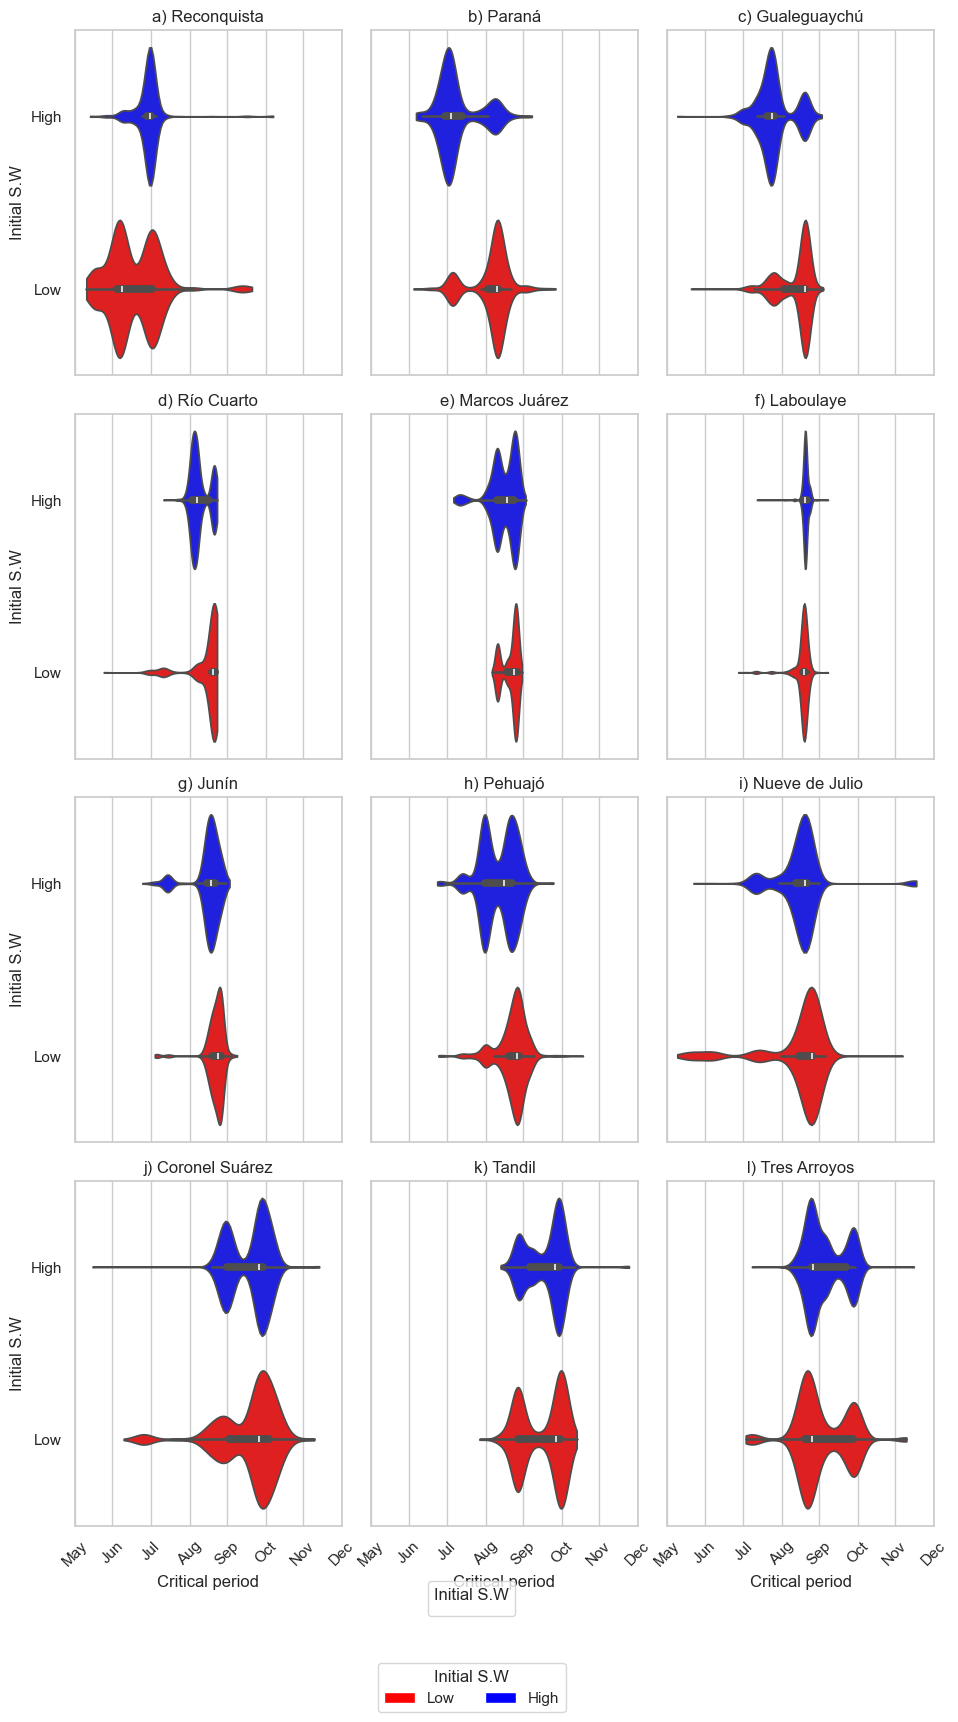

In [44]:
g = fp.facet_plot(
    df_simulations_idmax,
    sns.violinplot,
    cut=0,
    height=4, aspect=0.8,
    col="location",
    
    x="julian_day",y = "initial_sw",
    hue="initial_sw",
    palette={"Low":"red","High":"blue"},
    legend_title = "Initial S.W"
)

g.set(xlabel = "Critical period",ylabel="Initial S.W",
      xlim = [151,365],
     xticks = [151, 181, 212, 243, 273, 304, 334, 365],
xticklabels = ["May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
for ax in g.axes.flat:
  plt.setp(ax.get_xticklabels(), rotation=45)

handles, labels = g.axes.flat[0].get_legend_handles_labels()

g.fig.legend(
    handles,
    labels,
    title="Initial S.W",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2
)


handles = [
    Patch(facecolor="red", label="Low"),
    Patch(facecolor="blue", label="High")
]
g.fig.legend(
    handles=handles,
    title="Initial S.W",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2
)


plt.savefig(files_plots + "montecarlo_maxcorr_julian_day.png",dpi=300, bbox_inches='tight')

## Normal correlation

In [18]:
df_merge_correlations = df_merge.groupby(["location","julian_day","initial_sw"]).apply(
    lambda g: pd.Series({"pearson":np.corrcoef(g["prcp_sum_30_rollmean5"],g["yield_kg_ha"] )[1,0]
                        })
).dropna().reset_index()

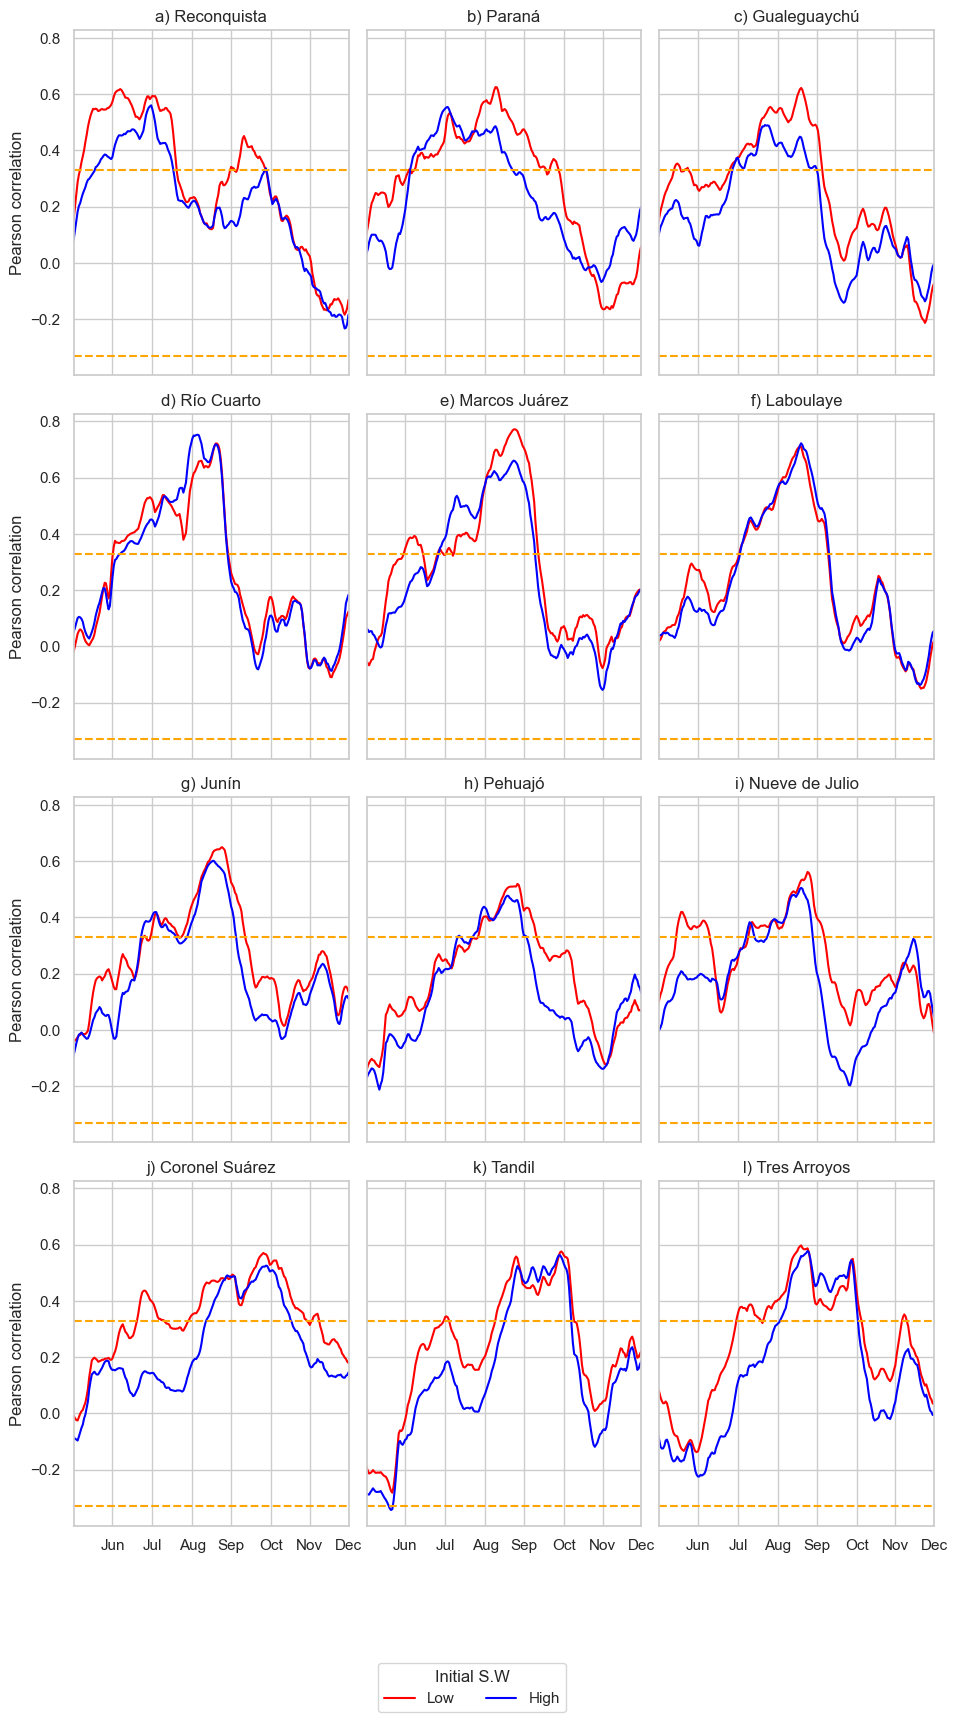

In [19]:


g = fp.facet_plot(
    df_merge_correlations,
    sns.lineplot, 
        height=4, aspect=0.8,
    col="location",
    hue_order = ["Low","High"],
    x="julian_day",y = "pearson",
    hue="initial_sw",
    palette={"Low":"red","High":"blue"},
    legend_title="Initial S.W"
)



# THresholds
g.refline(y=0.33, color="orange")
g.refline(y=-0.33, color = "orange")

g.set(ylabel="Pearson correlation",
    xlabel="",
    xticks =  [ 182, 213, 244, 274, 305, 335,365],
    xticklabels = ["Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    xlim = (152,365))


plt.savefig(files_plots + "correlation_series.png",dpi=300,bbox_inches='tight')

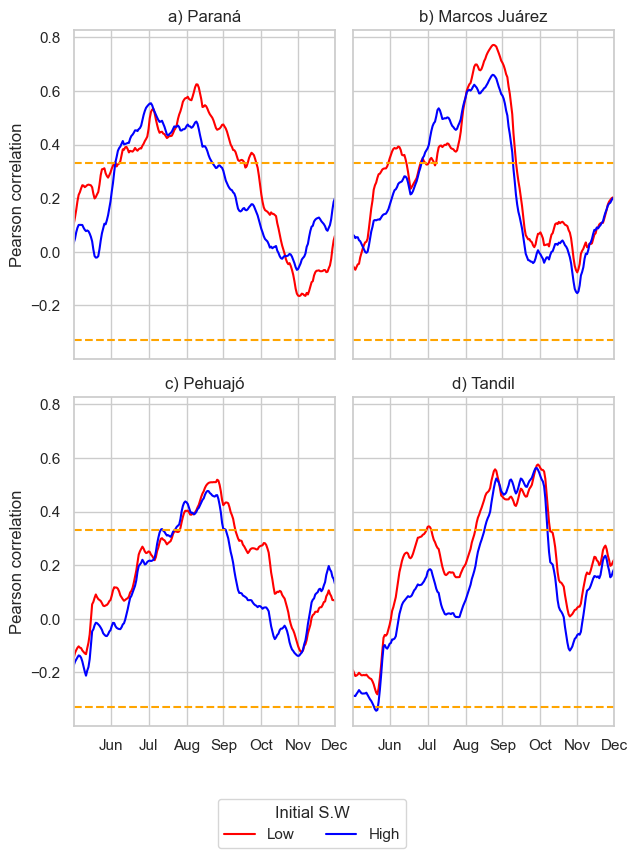

In [20]:
subgroup = ["Paraná","Marcos Juárez","Pehuajó","Tandil"]
df_sub = df_merge_correlations[df_merge_correlations["location"].isin(subgroup)].copy()

df_sub["location"] = (
    df_sub["location"]
    .cat.remove_unused_categories()
)

g = fp.facet_plot(
    df_sub,
    sns.lineplot, 
    col_wrap=2,
        height=4, aspect=0.8,
    col="location",
    hue_order = ["Low","High"],
    x="julian_day",y = "pearson",
    hue="initial_sw",
    palette={"Low":"red","High":"blue"},
    legend_title="Initial S.W"
)



# THresholds
g.refline(y=0.33, color="orange")
g.refline(y=-0.33, color = "orange")

g.set(ylabel="Pearson correlation",
    xlabel="",
    xticks =  [ 182, 213, 244, 274, 305, 335,365],
    xticklabels = ["Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    xlim = (152,365))


plt.savefig(files_plots + "correlation_series_subgroup.png",dpi=300,bbox_inches='tight')

### Window of maximum correlation

In [21]:
# Create "date" for the Julian day
df_merge_correlations["date"] = pd.Timestamp("2001-01-01") + pd.to_timedelta(
    df_merge_correlations["julian_day"]-1,unit="D")
df_merge_correlations["date"] = df_merge_correlations["date"].dt.strftime("%d %b")

In [22]:
# Get indices for the maximum pearson correlation
indices = df_merge_correlations.groupby(["location","initial_sw"])["pearson"].idxmax()
df_merge_correlations_idxmax = df_merge_correlations.iloc[indices.values,:].copy()

In [23]:
dftoplot = df_merge_correlations_idxmax.merge(df_locations,on = "location")
dftoplot = dftoplot.copy().pivot(index=["location","latitude","longitude"], 
                                   columns = "initial_sw",
                                              values = ["date","julian_day","pearson"]).reset_index()


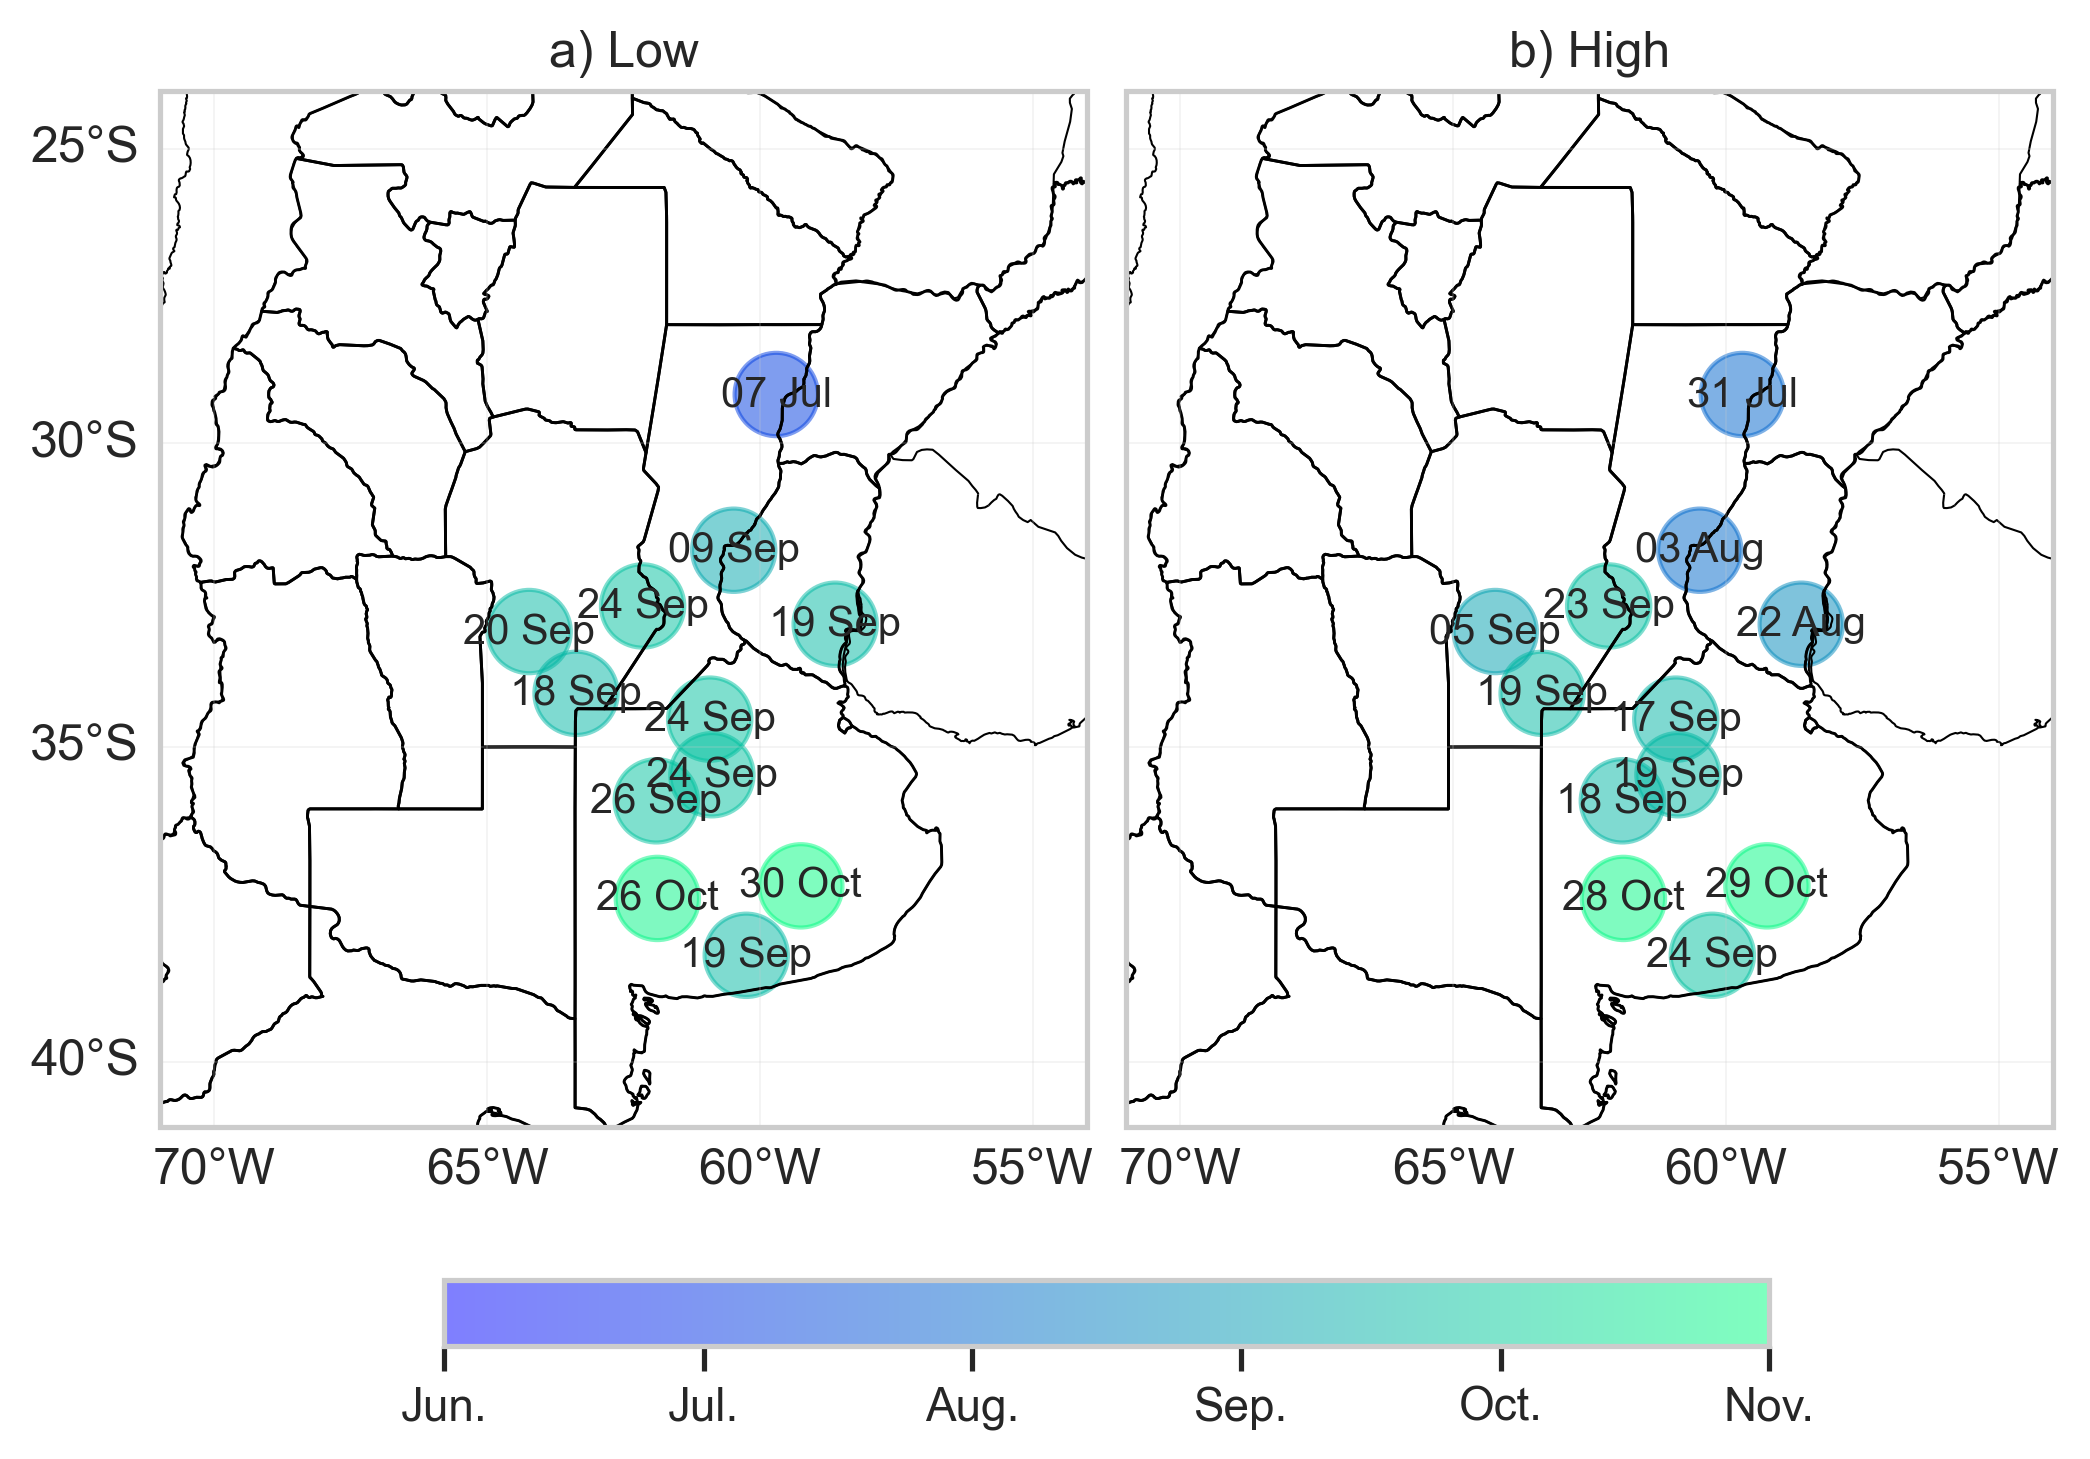

In [24]:
map_plot(longitude = dftoplot["longitude"],
    latitude = dftoplot["latitude"],
    texts  = [dftoplot["date"]["Low"],dftoplot["date"]["High"]],
    colors = [dftoplot["julian_day"]["Low"], dftoplot["julian_day"]["High"]],
    titles = ["a) Low","b) High"],
    cmap  = "winter",
    cbar_title = "",
    vmin=152, vmax=305,
    extend=None,
    cbar_ticks=[152,182,213,244,274,305],
    cbar_ticklabels=["Jun.","Jul.","Aug.","Sep.","Oct.","Nov."],
)

plt.savefig(files_plots + "map_max_pearson_date_initial_sw.png",bbox_inches='tight')

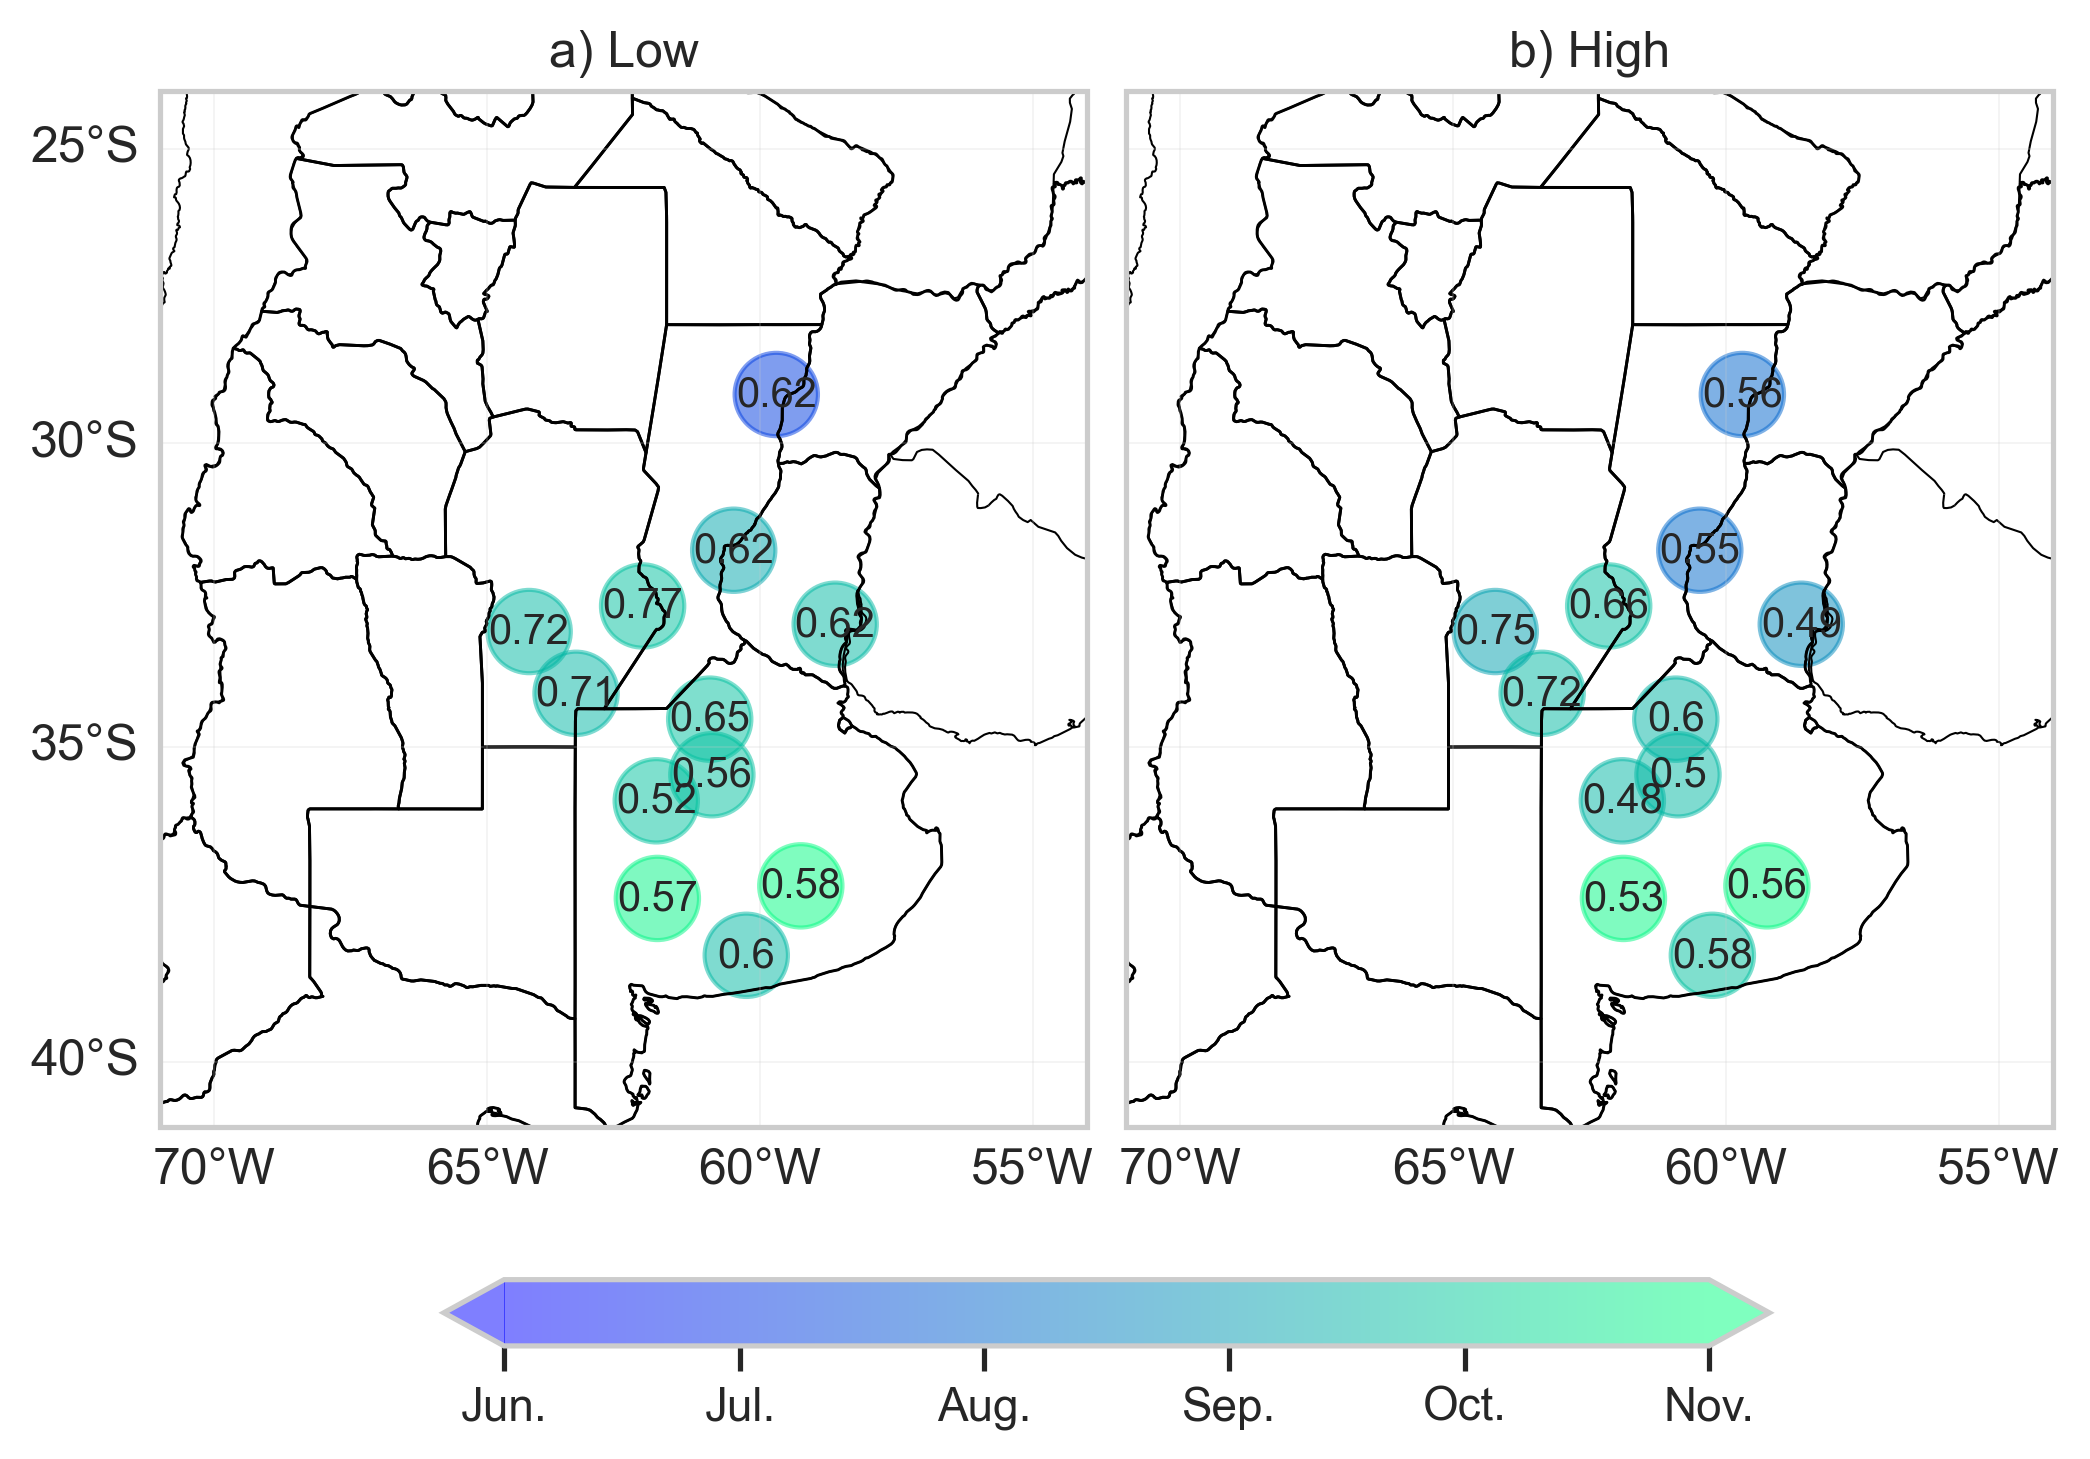

In [25]:
map_plot(longitude = dftoplot["longitude"],
    latitude = dftoplot["latitude"],
    texts  = [dftoplot["pearson"]["Low"].astype(float).round(2),dftoplot["pearson"]["High"].astype(float).round(2)],
    colors = [dftoplot["julian_day"]["Low"], dftoplot["julian_day"]["High"]],
    titles = ["a) Low","b) High"],
    cmap  = "winter",
    cbar_title = "",
    vmin=152, vmax=305,
    extend="both",
    cbar_ticks=[152,182,213,244,274,305],
    cbar_ticklabels=["Jun.","Jul.","Aug.","Sep.","Oct.","Nov."],
)

plt.savefig(files_plots + "map_max_pearson_initial_sw.png",bbox_inches='tight')

### save df_merge_correlations_idxmax

In [26]:
df_merge_correlations_idxmax.to_csv(files_dataout + "df_merge_correlations_idxmax.csv", index=False)

### Significant windows

Defined as the period with correlation higher than 0.33

In [27]:
# Ensure order of data
df_merge_correlations = df_merge_correlations.sort_values(by=["location","initial_sw","julian_day"]).copy()

In [28]:
# Window identification
# If value is greater than threhsold AND previous value is below threshold 
# If value is lower than threshold AND preivous value is over threshold#

idx_threshold = (
    ( (df_merge_correlations["pearson"].shift(1) < 0.33 ) &  # previous should be below threshold
    (df_merge_correlations["pearson"] >= 0.33)  # over threshold  
    )
    |
    (
    (df_merge_correlations["pearson"].shift(1) >= 0.33) &  # Previous was above or equal to threshold
    (df_merge_correlations["pearson"] < 0.33)              # Current dropped below threshold
    )
)

df_windows = df_merge_correlations[idx_threshold]
df_windows["Window_edge"]= np.where(df_windows["pearson"]>0.33,"Start","End")


In [29]:

list_windows = []

for (loc, sw), g in df_windows.groupby(["location", "initial_sw"]):

    starts = g[g["Window_edge"] == "Start"]
    ends = g[g["Window_edge"] == "End"]

    windows = starts["date"].values + " to " + ends["date"].values

    list_windows.append({
        "Location": loc,
        "Initial_SW": sw,
        "Critical_Windows": "; ".join(windows)
    })

df_windows_final = pd.DataFrame(list_windows)

In [30]:
df_windows_final.to_csv(files_dataout + "pearson_critical_windows.csv",index=False)

In [31]:
df_windows_final

,Location,Initial_SW,Critical_Windows
0,Reconquista,High,18 Jun to 18 Aug; 28 Oct to 29 Oct
1,Reconquista,Low,06 Jun to 20 Aug; 01 Oct to 04 Oct; 06 Oct to ...
2,Paraná,High,05 Jul to 23 Sep
3,Paraná,Low,04 Jul to 06 Jul; 09 Jul to 19 Oct; 21 Oct to ...
4,Gualeguaychú,High,28 Jul to 02 Oct
5,Gualeguaychú,Low,13 Jun to 18 Jun; 21 Jun to 24 Jun; 26 Jul to ...
6,Río Cuarto,High,08 Jul to 29 Sep
7,Río Cuarto,Low,02 Jul to 29 Sep
8,Marcos Juárez,High,27 Jul to 10 Oct
9,Marcos Juárez,Low,30 Jun to 15 Jul; 27 Jul to 31 Jul; 02 Aug to ...
